# 01 · Raw Data Audit

Look at `data/raw/SEER.csv` as delivered. Nothing is changed here.

| | |
|---|---|
| Dataset | SEER Breast Cancer Data (Teng, IEEE DataPort, 2019), doi:[10.21227/a9qy-ph35](https://doi.org/10.21227/a9qy-ph35) |
| Source | NCI SEER, November 2017 release |
| Cohort | women with infiltrating duct and lobular carcinoma, diagnosed 2006–2010 |
| Excluded by author | unknown tumour size or node counts, survival < 1 month |

The source does not say whether `Dead` means breast-cancer death, so it is treated as all-cause death.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from seer_survival import config as C
from seer_survival.plots import set_style, save_fig, STATUS_COLORS

set_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 1.26.4


## 1. Load the file without touching it

In [2]:
raw = pd.read_csv(C.RAW_DATA_PATH)
print(f"File: {C.RAW_DATA_PATH.name}  |  size on disk: {C.RAW_DATA_PATH.stat().st_size/1024:.1f} KB")
print(f"Rows: {raw.shape[0]:,}  |  Columns: {raw.shape[1]}")
print(f"Memory in pandas: {raw.memory_usage(deep=True).sum()/1024:.1f} KB")
raw.head()

File: SEER.csv  |  size on disk: 507.8 KB
Rows: 4,024  |  Columns: 16
Memory in pandas: 2834.0 KB


,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


In [3]:
raw.tail(3)

,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4021,53,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,9,Negative,Negative,4,2,107,Alive
4022,60,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,9,Positive,Positive,14,2,107,Alive
4023,62,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,8,Positive,Positive,1,1,107,Alive


## 2. Column names

Printing the names with `repr()` shows hidden whitespace, which a normal display does not.

In [4]:
cols = pd.DataFrame({
    "raw_name": [repr(c) for c in raw.columns],
    "dtype": raw.dtypes.astype(str).values,
    "n_unique": raw.nunique(dropna=False).values,
    "n_missing": raw.isna().sum().values,
    "example": [raw[c].dropna().iloc[0] if raw[c].notna().any() else None for c in raw.columns],
})
cols["issue"] = ""
cols.loc[cols.raw_name.str.contains(r" '$"), "issue"] = "trailing space in header"
cols.loc[cols.n_missing == len(raw), "issue"] = "column is completely empty"
cols.loc[cols.raw_name.str.contains("Reginol"), "issue"] = "typo: 'Reginol' -> 'Regional'"
cols

,raw_name,dtype,n_unique,n_missing,example,issue
0,'Age',int64,40,0,43,
1,'Race ',object,3,0,"Other (American Indian/AK Native, Asian/Pacifi...",trailing space in header
2,'Marital Status',object,5,0,Married (including common law),
3,'Unnamed: 3',float64,1,4024,None,column is completely empty
4,'T Stage ',object,4,0,T2,trailing space in header
5,'N Stage',object,3,0,N3,
6,'6th Stage',object,5,0,IIIC,
7,'Grade',object,4,0,Moderately differentiated; Grade II,
8,'A Stage',object,2,0,Regional,
9,'Tumor Size',int64,110,0,40,


## 3. Missing values

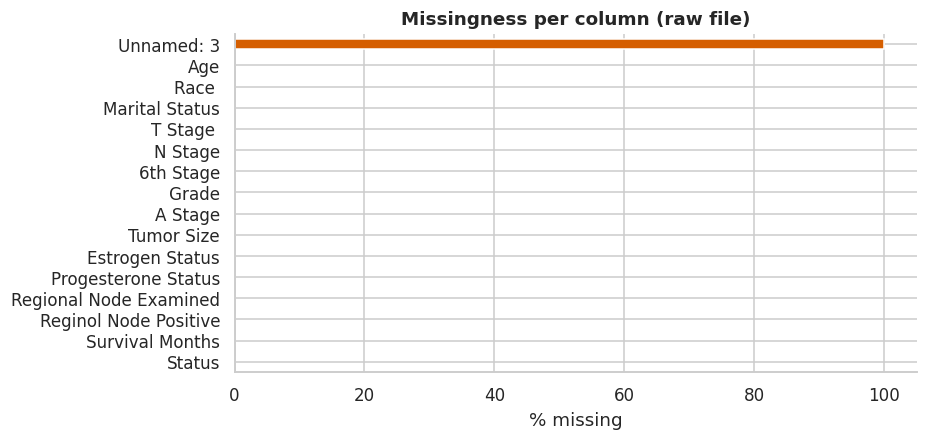

Columns with any missing value: {'Unnamed: 3': 100.0}


In [5]:
miss = raw.isna().mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
miss.plot.barh(ax=ax, color=["#D55E00" if v > 0 else "#0072B2" for v in miss])
ax.set_xlabel("% missing"); ax.set_title("Missingness per column (raw file)")
ax.invert_yaxis()
save_fig(fig, "01_missingness"); plt.show()
print("Columns with any missing value:", miss[miss > 0].to_dict())

## 4. Categorical columns: levels and frequencies

In [6]:
cat_cols = raw.select_dtypes("object").columns
for c in cat_cols:
    vc = raw[c].value_counts(dropna=False)
    print(f"\n--- {c!r}  ({len(vc)} levels)")
    print(pd.DataFrame({"n": vc, "%": (vc / len(raw) * 100).round(1)}).to_string())


--- 'Race '  (3 levels)
                                                              n     %
Race                                                                 
White                                                      3413  84.8
Other (American Indian/AK Native, Asian/Pacific Islander)   320   8.0
Black                                                       291   7.2

--- 'Marital Status'  (5 levels)
                                   n     %
Marital Status                            
Married (including common law)  2643  65.7
Single (never married)           615  15.3
Divorced                         486  12.1
Widowed                          235   5.8
Separated                         45   1.1

--- 'T Stage '  (4 levels)
             n     %
T Stage             
T2        1786  44.4
T1        1603  39.8
T3         533  13.2
T4         102   2.5

--- 'N Stage'  (3 levels)
            n     %
N Stage            
N1       2732  67.9
N2        820  20.4
N3        472  11.7

--- '6th

## 5. Numeric columns: distribution summary

In [7]:
num = raw.select_dtypes("number").drop(columns=[c for c in raw.columns if raw[c].isna().all()])
summary = num.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary["skew"] = num.skew()
summary["kurtosis"] = num.kurtosis()
summary["n_zero"] = (num == 0).sum()
summary.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis,n_zero
Age,4024.0,53.97,8.96,30.0,33.0,39.00,47.0,54.0,61.0,68.0,69.00,69.0,-0.22,-0.76,0
Tumor Size,4024.0,30.47,21.12,1.0,4.0,9.00,16.0,25.0,38.0,75.0,102.54,140.0,1.74,3.63,0
Regional Node Examined,4024.0,14.36,8.10,1.0,1.0,2.00,9.0,14.0,19.0,28.0,38.77,61.0,0.83,1.65,0
Reginol Node Positive,4024.0,4.16,5.11,1.0,1.0,1.00,1.0,2.0,5.0,15.0,26.00,46.0,2.70,8.98,0
Survival Months,4024.0,71.30,22.92,1.0,8.0,26.15,56.0,73.0,90.0,103.0,107.00,107.0,-0.59,0.02,0


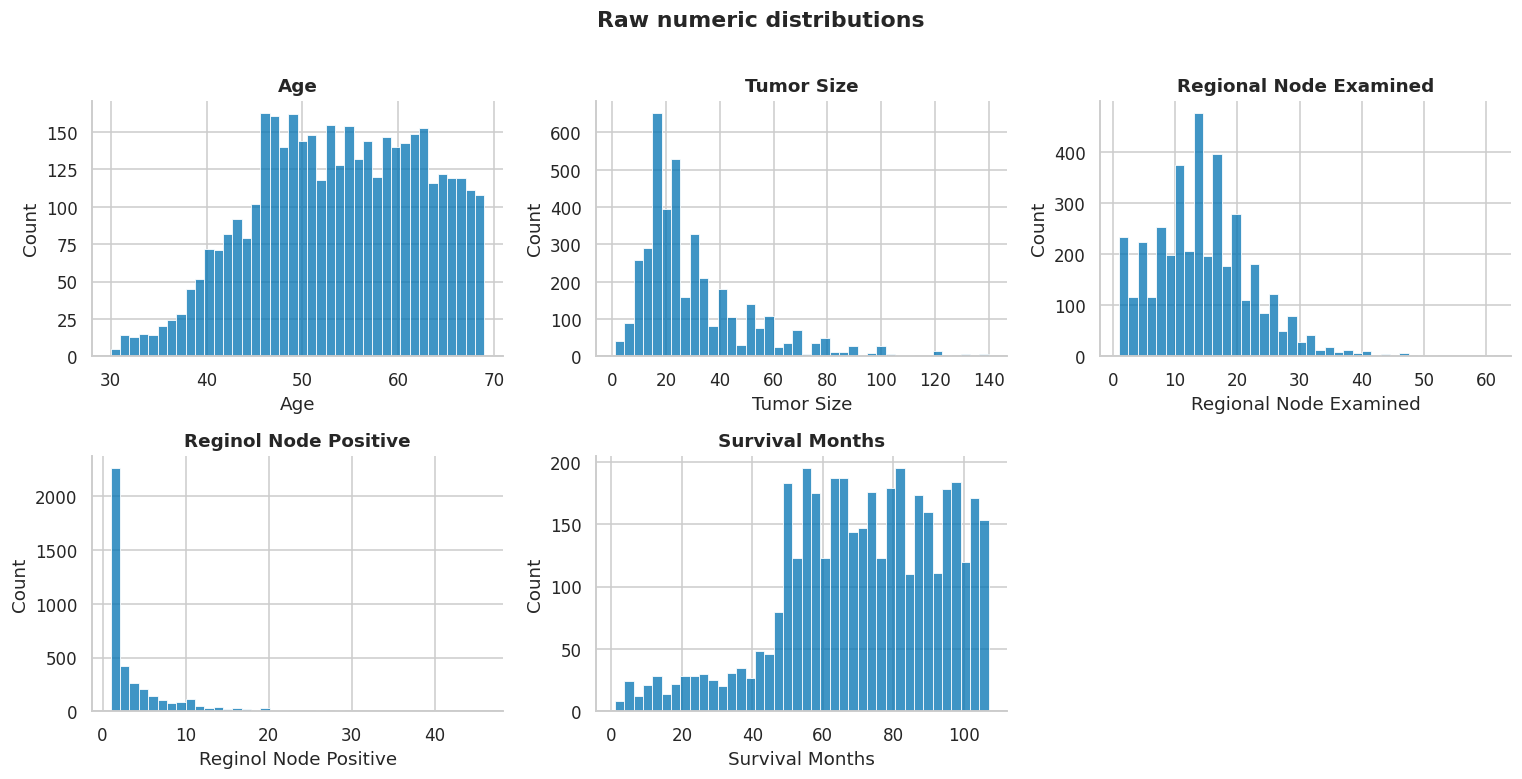

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), num.columns):
    sns.histplot(num[c], bins=40, ax=ax, color="#0072B2")
    ax.set_title(c)
axes.ravel()[-1].axis("off")
fig.suptitle("Raw numeric distributions", y=1.01, fontweight="bold")
fig.tight_layout(); save_fig(fig, "01_numeric_raw"); plt.show()

## 6. Duplicates

In [9]:
dups = raw[raw.duplicated(keep=False)]
print("Exact duplicate rows:", raw.duplicated().sum())
dups

Exact duplicate rows: 1


,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
1009,63,White,Married (including common law),NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,17,Positive,Positive,9,1,56,Alive
1010,63,White,Married (including common law),NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,17,Positive,Positive,9,1,56,Alive


There is no patient identifier, and the features are coarse (age in years, size in mm, categories). Two different women can therefore have identical rows. A duplicate row is **not** proof of a data-entry error, so the decision is made in notebook 02.

## 7. The two outcome columns

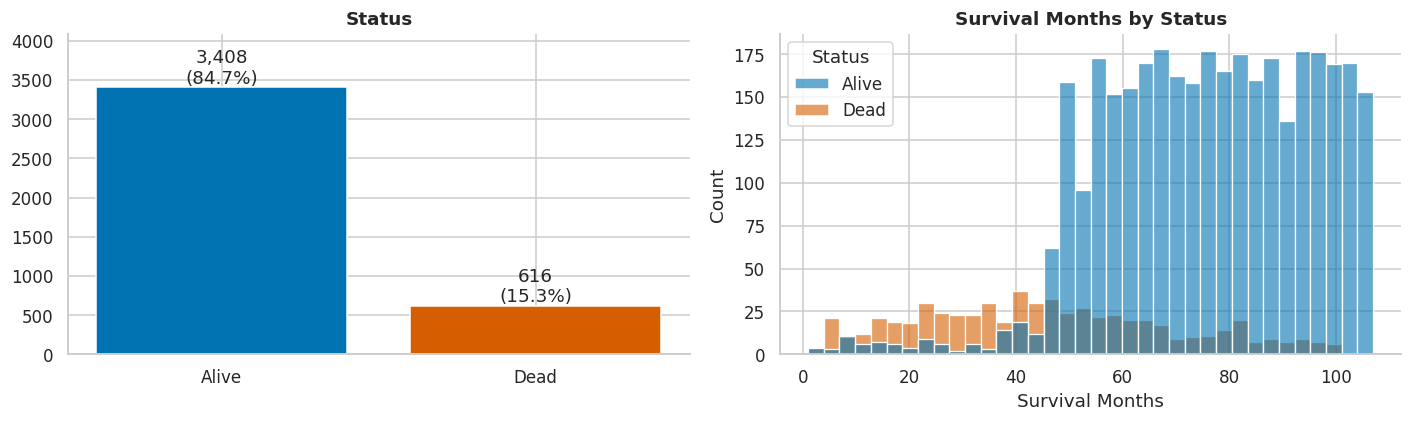

         count  mean   std  min   25%   50%   75%    max
Status                                                  
Alive   3408.0  75.9  19.4  1.0  61.0  77.0  92.0  107.0
Dead     616.0  45.6  24.0  2.0  27.0  44.0  61.0  102.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vc = raw["Status"].value_counts()
axes[0].bar(vc.index, vc.values, color=[STATUS_COLORS[k] for k in vc.index])
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(raw):.1%})", ha="center", va="bottom")
axes[0].set_title("Status"); axes[0].set_ylim(0, vc.max() * 1.2)
sns.histplot(data=raw, x="Survival Months", hue="Status", bins=36, ax=axes[1],
             palette=STATUS_COLORS, multiple="layer", alpha=.6)
axes[1].set_title("Survival Months by Status")
fig.tight_layout(); save_fig(fig, "01_outcomes"); plt.show()

print(raw.groupby("Status")["Survival Months"].describe().round(1))

## 8. Is `Survival Months` a leakage variable?

Patients who died have much shorter follow-up. `Survival Months` is the time to death or last contact, so it is only known after the outcome. Using it to predict `Status` is target leakage (Kaufman et al., 2012). The size of the effect is measured in notebook 06.

In [11]:
from sklearn.metrics import roc_auc_score
y = (raw["Status"] == "Dead").astype(int)
auc_time_only = roc_auc_score(y, -raw["Survival Months"])
print(f"ROC-AUC of 'shorter follow-up => Dead' using Survival Months alone: {auc_time_only:.3f}")

ROC-AUC of 'shorter follow-up => Dead' using Survival Months alone: 0.833


## 9. Second observation: censoring

`Status = Alive` does **not** mean the patient survived five years. It means she was alive at her last follow-up.

In [12]:
alive = raw["Status"] == "Alive"
for h in (36, 60, 84):
    n = (alive & (raw["Survival Months"] < h)).sum()
    print(f"Alive but followed < {h} months: {n:4d}  ({n/alive.sum():.1%} of alive patients)")

Alive but followed < 36 months:   67  (2.0% of alive patients)
Alive but followed < 60 months:  754  (22.1% of alive patients)
Alive but followed < 84 months: 2094  (61.4% of alive patients)


Any "died within 5 years" label has to deal with these patients. Survival models deal with them directly; the classification task in notebook 06 removes them from the binary label (documented in `src/seer_survival/targets.py`).

## 10. Summary

| Finding | Action |
|---|---|
| Trailing spaces in `'Race '`, `'T Stage '` | strip (02) |
| `Unnamed: 3` is empty | drop (02) |
| Typo `Reginol Node Positive` | rename (02) |
| No missing values otherwise | no imputation |
| 1 duplicate row, no patient ID | review (02) |
| Tumour size and node counts are right-skewed | log transform for linear models (05) |
| `Survival Months` separates the classes | never an input (06) |
| Many alive patients followed < 5 years | survival models (04, 07), 5-year label rule (06) |
| About 15 % deaths | use AUC, PR-AUC, Brier rather than accuracy (06) |